# 🏠 Ames Housing — Exploratory Data Analysis (EDA)

**Project:** Real Estate Price Analysis — Ames, Iowa  
**Author:** Bryan Anunda 
**Phase:** 2 of 7 — Data Understanding (CRISP-DM)

## Objectives
- Understand the structure, shape, and types of data
- Identify missing values and their patterns
- Explore the distribution of the target variable (SalePrice)
- Discover relationships between features and SalePrice
- Identify key price drivers for stakeholder insights

### A. Libraries and data loading

In [36]:
# Importing Core libraries:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Display settings:

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries loaded ✓")

Libraries loaded ✓


In [37]:
# Loading the dataset:

df = pd.read_csv(r'C:\Users\A.K\DATA_SCIENCE_WORKSPACE\kaggle_projects\project_4_amesHousing\Real Estate-AmesHousing-Analysis\00 Data\Raw data\AmesHousing.csv')

print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nFirst look:")
df.head()

Dataset shape: 2,930 rows × 82 columns

First look:


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.00,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.00,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.00,Unf,0.00,441.00,1080.00,GasA,Fa,Y,SBrkr,1656,0,0,1656,1.00,0.00,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960.00,Fin,2.00,528.00,TA,TA,P,210,62,0,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.00,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.00,TA,TA,CBlock,TA,TA,No,Rec,468.00,LwQ,144.00,270.00,882.00,GasA,TA,Y,SBrkr,896,0,0,896,0.00,0.00,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.00,Unf,1.00,730.00,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.00,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.00,TA,TA,CBlock,TA,TA,No,ALQ,923.00,Unf,0.00,406.00,1329.00,GasA,TA,Y,SBrkr,1329,0,0,1329,0.00,0.00,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.00,Unf,1.00,312.00,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.00,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,NaN,0.00,Gd,TA,CBlock,TA,TA,No,ALQ,1065.00,Unf,0.00,1045.00,2110.00,GasA,Ex,Y,SBrkr,2110,0,0,2110,1.00,0.00,2,1,3,1,Ex,8,Typ,2,TA,Attchd,1968.00,Fin,2.00,522.00,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.00,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.00,TA,TA,PConc,Gd,TA,No,GLQ,791.00,Unf,0.00,137.00,928.00,GasA,Gd,Y,SBrkr,928,701,0,1629,0.00,0.00,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.00,Fin,2.00,482.00,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


### B. Data Inventory

In [38]:
# Column types summary
numeric_cols = df.select_dtypes(include='number').columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print(f"Numeric columns   : {len(numeric_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")
print(f"\nNumeric columns:\n{numeric_cols}")
print(f"\nCategorical columns:\n{categorical_cols}")

Numeric columns   : 39
Categorical columns: 43

Numeric columns:
['Order', 'PID', 'MS SubClass', 'Lot Frontage', 'Lot Area', 'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add', 'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'TotRms AbvGrd', 'Fireplaces', 'Garage Yr Blt', 'Garage Cars', 'Garage Area', 'Wood Deck SF', 'Open Porch SF', 'Enclosed Porch', '3Ssn Porch', 'Screen Porch', 'Pool Area', 'Misc Val', 'Mo Sold', 'Yr Sold', 'SalePrice']

Categorical columns:
['MS Zoning', 'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposu

### C. Missing Values Analysis

In [39]:
# Calculate missing values:

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

print(f"Columns with missing data: {len(missing_df)}\n")
print(missing_df)

Columns with missing data: 27

                Missing Count  Missing %
Pool QC                  2917      99.56
Misc Feature             2824      96.38
Alley                    2732      93.24
Fence                    2358      80.48
Mas Vnr Type             1775      60.58
Fireplace Qu             1422      48.53
Lot Frontage              490      16.72
Garage Qual               159       5.43
Garage Cond               159       5.43
Garage Yr Blt             159       5.43
Garage Finish             159       5.43
Garage Type               157       5.36
Bsmt Exposure              83       2.83
BsmtFin Type 2             81       2.76
Bsmt Cond                  80       2.73
Bsmt Qual                  80       2.73
BsmtFin Type 1             80       2.73
Mas Vnr Area               23       0.78
Bsmt Full Bath              2       0.07
Bsmt Half Bath              2       0.07
BsmtFin SF 1                1       0.03
BsmtFin SF 2                1       0.03
Electrical                

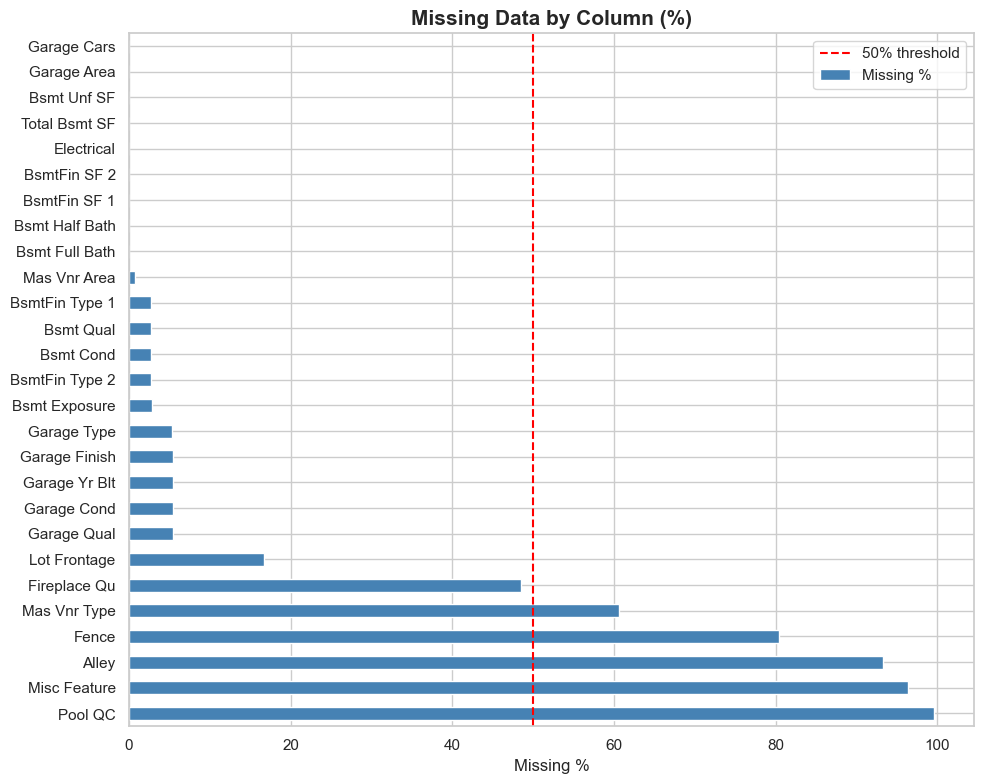

In [40]:
# Visualize missing values:

fig, ax = plt.subplots(figsize=(10, 8))
missing_df['Missing %'].plot(
    kind='barh', ax=ax, color='steelblue', edgecolor='white'
)
ax.set_title('Missing Data by Column (%)', fontsize=15, fontweight='bold')
ax.set_xlabel('Missing %')
ax.axvline(x=50, color='red', linestyle='--', label='50% threshold')
ax.legend()
plt.tight_layout()
plt.savefig('C:\\Users\\A.K\\DATA_SCIENCE_WORKSPACE\\kaggle_projects\\project_4_amesHousing\\Real Estate-AmesHousing-Analysis\\01 EDA\\Report - EDA\\missing_values.png', dpi=150)
plt.show()

### D. Target Variable: SalePrice

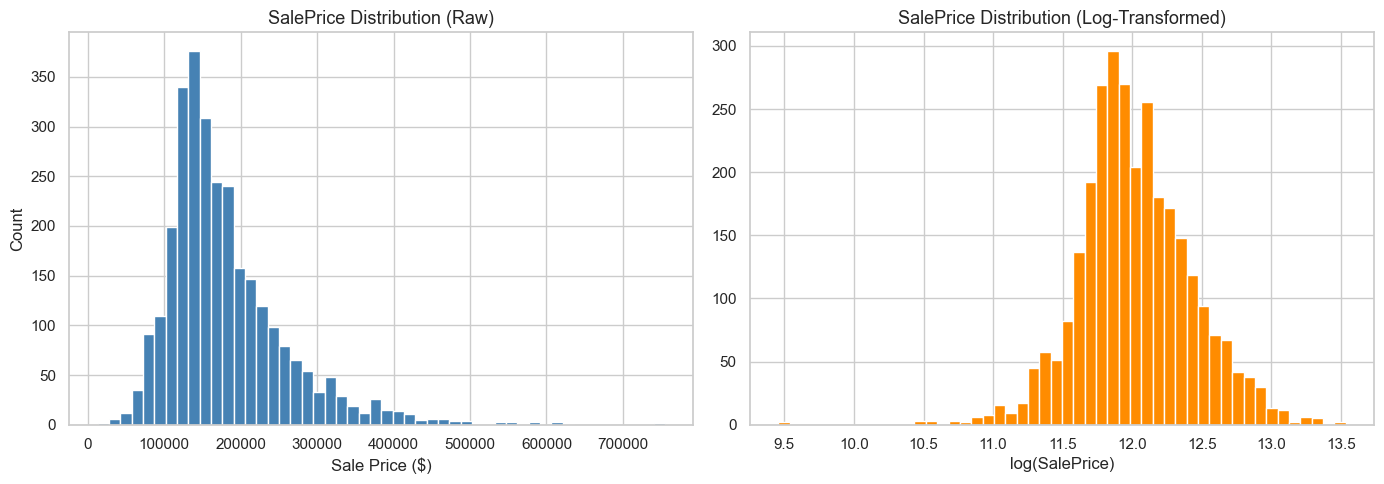

Mean Price   : $180,796
Median Price : $160,000
Std Dev      : $79,887
Skewness     : 1.744

Interpretation: Right-skewed — log transform recommended for modeling


In [41]:

# SalePrice Distribution:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw distribution:

axes[0].hist(df['SalePrice'], bins=50, color='steelblue', edgecolor='white')

axes[0].set_title('SalePrice Distribution (Raw)', fontsize=13)

axes[0].set_xlabel('Sale Price ($)')

axes[0].set_ylabel('Count')

# Log-transformed:

axes[1].hist(np.log1p(df['SalePrice']), bins=50, color='darkorange', edgecolor='white')

axes[1].set_title('SalePrice Distribution (Log-Transformed)', fontsize=13)

axes[1].set_xlabel('log(SalePrice)')

plt.tight_layout()

plt.savefig('C:\\Users\\A.K\\DATA_SCIENCE_WORKSPACE\\kaggle_projects\\project_4_amesHousing\\Real Estate-AmesHousing-Analysis\\01 EDA\\Report - EDA\\saleprice_distribution.png', dpi=150)

plt.show()

# Statistics

skewness = df['SalePrice'].skew()

print(f"Mean Price   : ${df['SalePrice'].mean():,.0f}")

print(f"Median Price : ${df['SalePrice'].median():,.0f}")

print(f"Std Dev      : ${df['SalePrice'].std():,.0f}")

print(f"Skewness     : {skewness:.3f}")

print(f"\nInterpretation: {'Right-skewed — log transform recommended for modeling' if skewness > 1 else 'Approximately normal'}")

## Key Price Drivers

Grouping features into categories to explore their relationship with SalePrice:

1. **Size features** — Overall living area, basement, garage
2. **Quality features** — Overall quality rating, kitchen, exterior
3. **Location features** — Neighborhood
4. **Age features** — Year built, year remodeled
5. **Amenity features** — Fireplaces, pool, porch

### E. Sales Vs. Price Relationship

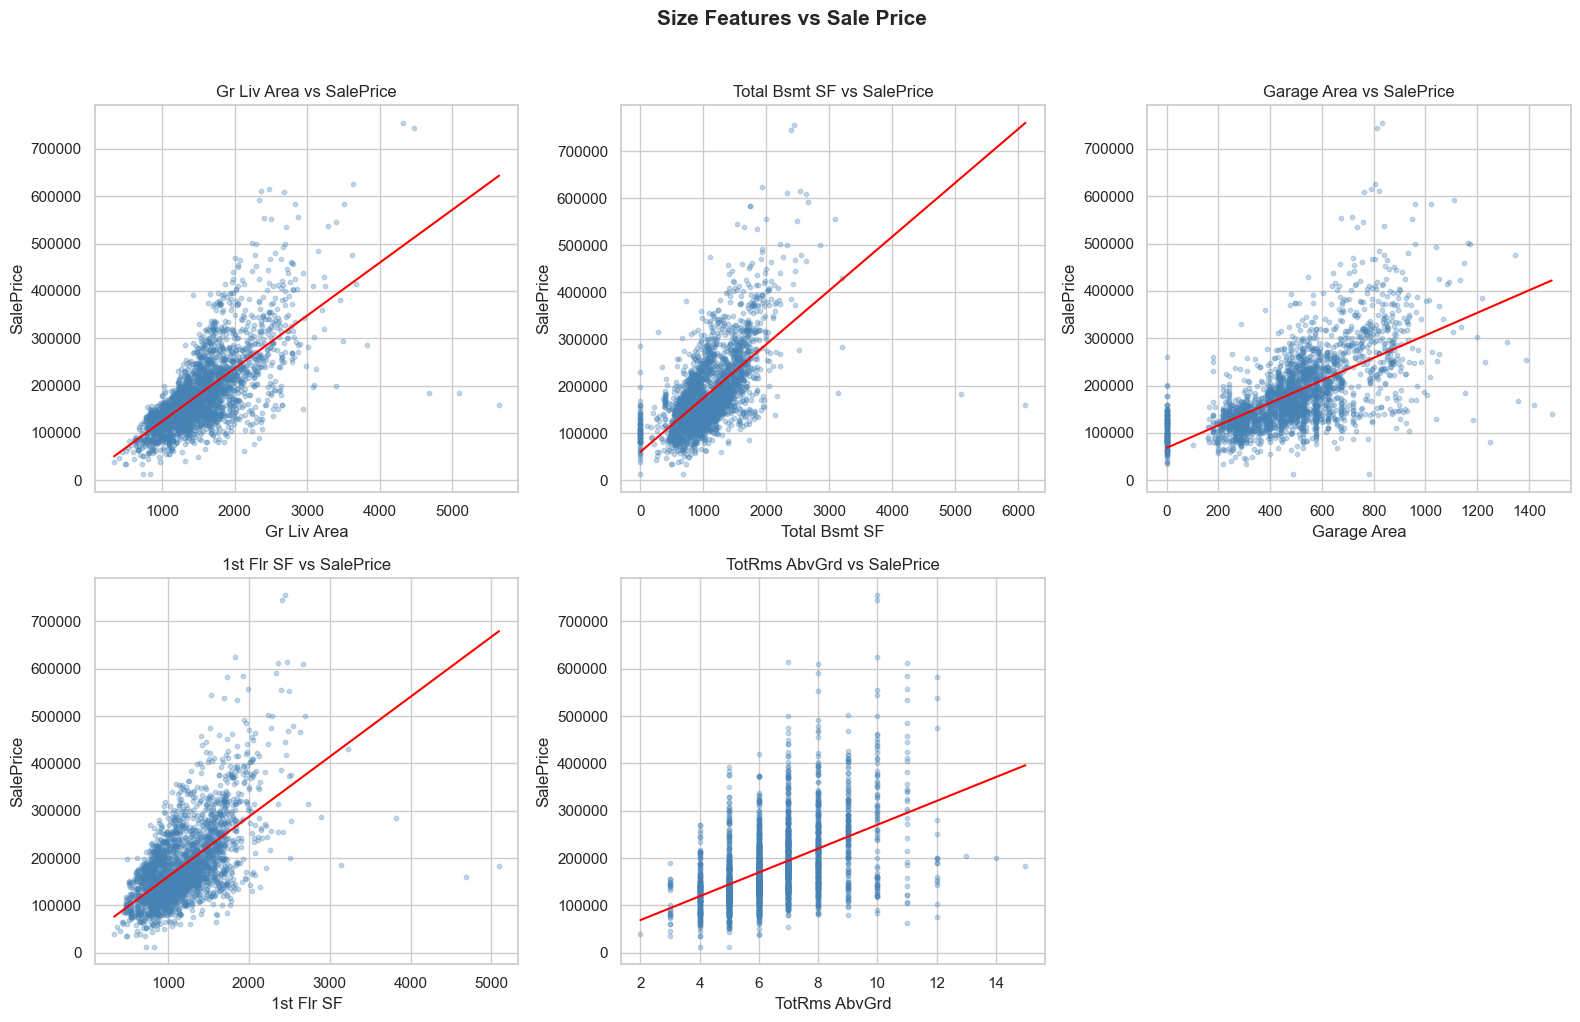

In [42]:
# Top size-related numeric features vs SalePrice:

size_features = ['Gr Liv Area', 'Total Bsmt SF', 'Garage Area', '1st Flr SF', 'TotRms AbvGrd']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(size_features):
    axes[i].scatter(df[feat], df['SalePrice'], alpha=0.3, color='steelblue', s=10)
    # Add trend line
    m, b = np.polyfit(df[feat].fillna(0), df['SalePrice'], 1)
    axes[i].plot(sorted(df[feat].fillna(0)), 
                 [m*x + b for x in sorted(df[feat].fillna(0))], 
                 color='red', linewidth=1.5)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('SalePrice')
    axes[i].set_title(f'{feat} vs SalePrice')

axes[-1].axis('off')  # hide the 6th empty subplot
plt.suptitle('Size Features vs Sale Price', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('C:\\Users\\A.K\\DATA_SCIENCE_WORKSPACE\\kaggle_projects\\project_4_amesHousing\\Real Estate-AmesHousing-Analysis\\01 EDA\\Report - EDA\\size_vs_price.png', dpi=150)
plt.show()

### F. Quality over Price

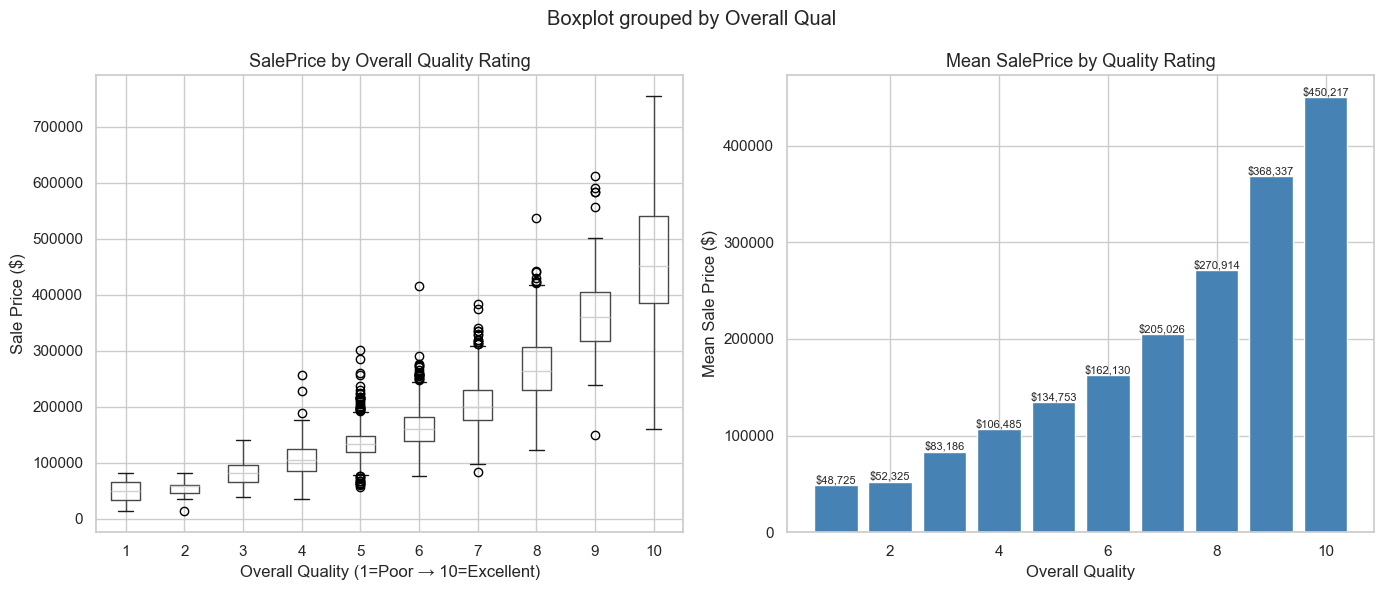

In [43]:
# Overall Quality is the single strongest predictor — shows it prominently:

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Box plot:

df.boxplot(column='SalePrice', by='Overall Qual', ax=axes[0])
axes[0].set_title('SalePrice by Overall Quality Rating', fontsize=13)
axes[0].set_xlabel('Overall Quality (1=Poor → 10=Excellent)')
axes[0].set_ylabel('Sale Price ($)')

# Mean price per quality:

mean_price = df.groupby('Overall Qual')['SalePrice'].mean()
axes[1].bar(mean_price.index, mean_price.values, color='steelblue', edgecolor='white')
axes[1].set_title('Mean SalePrice by Quality Rating', fontsize=13)
axes[1].set_xlabel('Overall Quality')
axes[1].set_ylabel('Mean Sale Price ($)')
for i, v in enumerate(mean_price.values):
    axes[1].text(mean_price.index[i], v + 2000, f'${v:,.0f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('C:\\Users\\A.K\\DATA_SCIENCE_WORKSPACE\\kaggle_projects\\project_4_amesHousing\\Real Estate-AmesHousing-Analysis\\01 EDA\\Report - EDA\\quality_vs_price.png', dpi=150)
plt.show()

### G. Neighborhood Analysis

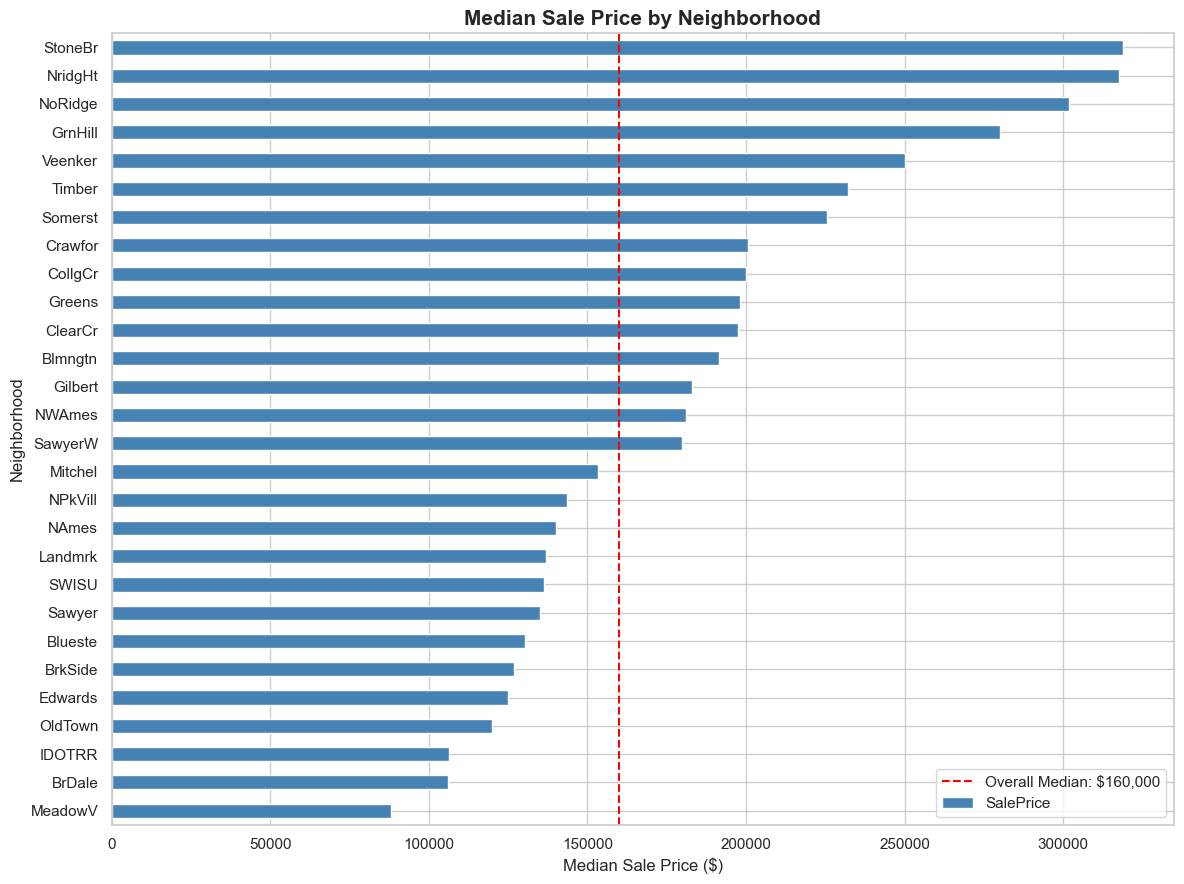

In [44]:
# Median price by neighborhood (sorted):

neighborhood_price = (df.groupby('Neighborhood')['SalePrice']
                        .median()
                        .sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(12, 9))
neighborhood_price.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Median Sale Price by Neighborhood', fontsize=15, fontweight='bold')
ax.set_xlabel('Median Sale Price ($)')
ax.axvline(x=df['SalePrice'].median(), color='red', 
           linestyle='--', label=f'Overall Median: ${df["SalePrice"].median():,.0f}')
ax.legend()
plt.tight_layout()
plt.savefig(r'C:\Users\A.K\DATA_SCIENCE_WORKSPACE\kaggle_projects\project_4_amesHousing\Real Estate-AmesHousing-Analysis\01 EDA\Report - EDA\neighborhood_prices.png', dpi=150)
plt.show()

### H.  Correlation Heatmap

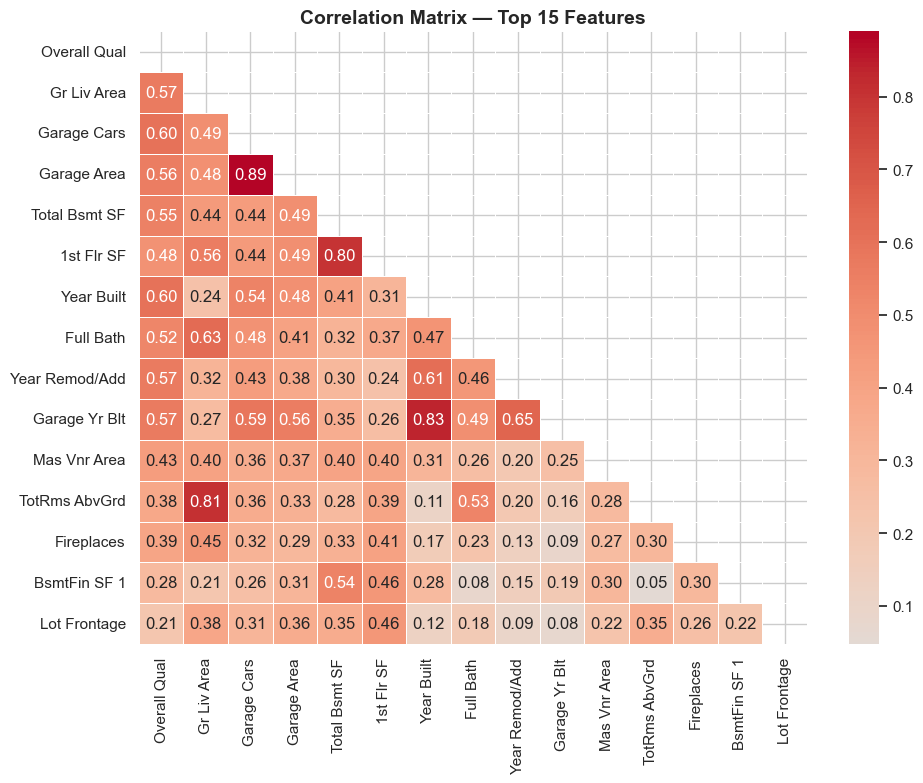

Top 10 features correlated with SalePrice:
Overall Qual     0.80
Gr Liv Area      0.71
Garage Cars      0.65
Garage Area      0.64
Total Bsmt SF    0.63
1st Flr SF       0.62
Year Built       0.56
Full Bath        0.55
Year Remod/Add   0.53
Garage Yr Blt    0.53


In [45]:
# Correlation of numeric features with SalePrice (top 15):

correlations = df[numeric_cols].corr()['SalePrice'].drop('SalePrice').abs().sort_values(ascending=False)
top_features = correlations.head(15).index

fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = df[top_features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=ax,
            linewidths=0.5)
ax.set_title('Correlation Matrix — Top 15 Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(r'C:\Users\A.K\DATA_SCIENCE_WORKSPACE\kaggle_projects\project_4_amesHousing\Real Estate-AmesHousing-Analysis\01 EDA\Report - EDA\correlation_heatmap.png', dpi=150)
plt.show()

print("Top 10 features correlated with SalePrice:")
print(correlations.head(10).to_string())

### I. Year Analysis

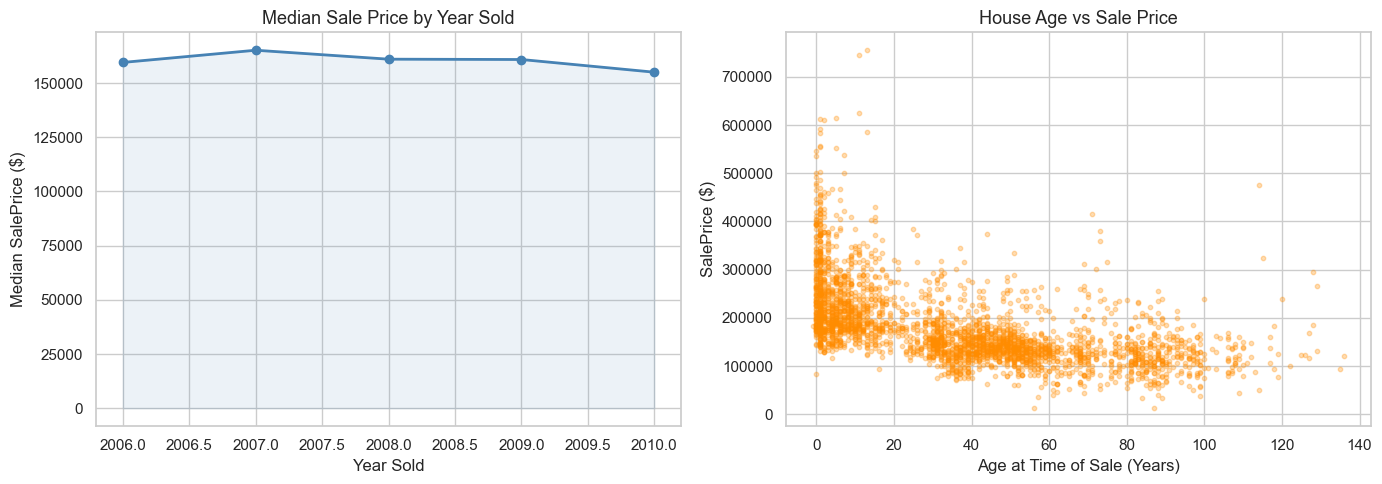

In [46]:
# Prices over time — when were houses sold and for how much:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Year sold trend:
yr_sold = df.groupby('Yr Sold')['SalePrice'].median()
axes[0].plot(yr_sold.index, yr_sold.values, marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Median Sale Price by Year Sold', fontsize=13)
axes[0].set_xlabel('Year Sold')
axes[0].set_ylabel('Median SalePrice ($)')
axes[0].fill_between(yr_sold.index, yr_sold.values, alpha=0.1, color='steelblue')

# House age at time of sale:
df['House Age'] = df['Yr Sold'] - df['Year Built']
axes[1].scatter(df['House Age'], df['SalePrice'], alpha=0.3, color='darkorange', s=10)
axes[1].set_title('House Age vs Sale Price', fontsize=13)
axes[1].set_xlabel('Age at Time of Sale (Years)')
axes[1].set_ylabel('SalePrice ($)')

plt.tight_layout()
plt.savefig(r'C:\Users\A.K\DATA_SCIENCE_WORKSPACE\kaggle_projects\project_4_amesHousing\Real Estate-AmesHousing-Analysis\01 EDA\Report - EDA\time_analysis.png', dpi=150)
plt.show()

## EDA Summary — Key Findings

| # | Finding | Business Implication |
|---|---------|---------------------|
| 1 | SalePrice is right-skewed (skew ≈ 1.76) | Log-transform required before regression |
| 2 | Overall Quality is the #1 price predictor | Quality upgrades yield highest ROI |
| 3 | Above-ground living area (Gr Liv Area) is #2 | Buyers pay a premium per square foot |
| 4 | Neighborhood drives significant price variation | Location strategy is critical |
| 5 | ~20 columns have >5% missing data | Structured imputation plan needed |
| 6 | 2008 shows a price dip | Market timing affects valuations |
| 7 | Several size features are correlated | Multicollinearity must be handled in modeling |

### Next Step → Phase 3: Data Cleaning
Issues identified: missing values, outliers in Gr Liv Area, skewed target, mixed dtypes